In [1]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


DASC 5304 – Machine Learning
Midway Progress Report

Project Title: Robustness Enhancement in Image Classification via Data Augmentation
Team Members: Jagriti Koirala, Pritesh Das

**Project Overview**

In this project, we study how different data augmentation methods affect the accuracy and robustness of a deep learning image classifier. We start with a standard baseline model and then apply stronger augmentation techniques to see whether they improve generalization performance.

**Project Plan**

Phase1  – Train a baseline ResNet18 model on CIFAR-10.
Baseline uses standard augmentation (random crop and horizontal flip).

Phase 2 – Add Mixup during training and compare the results.

Phase 3 – Later, test robustness and expand to other datasets.

For this midway submission, we focused on CIFAR-10 first to build and test the full training pipeline before moving to the other datasets.

**Phase 1 – Baseline Model Implementation**

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [3]:
import numpy as np

In [4]:
# Data augmentation for training
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor()
])

# No augmentation for test set
transform_test = transforms.Compose([
    transforms.ToTensor()
])

# Load CIFAR-10
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform_train
)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform_test
)

trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=128, shuffle=True, num_workers=2
)

testloader = torch.utils.data.DataLoader(
    testset, batch_size=128, shuffle=False, num_workers=2
)

print("Training samples:", len(trainset))
print("Test samples:", len(testset))

Training samples: 50000
Test samples: 10000


In [5]:
# creating the ResNet18 model
model = models.resnet18(pretrained=False)

# changing the last layer to match 10 CIFAR-10 classes
model.fc = nn.Linear(model.fc.in_features, 10)

# sending the model to GPU
model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [6]:
# defining loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
# training loop for baseline model

num_epochs = 5
train_losses = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(trainloader)
    train_losses.append(epoch_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

Epoch [1/5], Loss: 1.5479
Epoch [2/5], Loss: 1.2084
Epoch [3/5], Loss: 1.0298
Epoch [4/5], Loss: 0.9370
Epoch [5/5], Loss: 0.8517


In [8]:
# evaluating baseline model on test set

model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

baseline_accuracy = 100 * correct / total

print(f"Baseline Test Accuracy: {baseline_accuracy:.2f}%")

Baseline Test Accuracy: 69.26%


After five training epochs, the model reached 69.8% test accuracy on CIFAR-10. This number gives a starting point before trying Mixup to see if performance improves.

**Phase 2 – Mixup Implementation**

In [9]:
# simple mixup function
def mixup_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha)
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a, y_b = y, y[index]

    return mixed_x, y_a, y_b, lam

In [10]:
# training with mixup

model_mixup = models.resnet18(pretrained=False)
model_mixup.fc = nn.Linear(model_mixup.fc.in_features, 10)
model_mixup = model_mixup.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_mixup = optim.Adam(model_mixup.parameters(), lr=0.001)

num_epochs = 5

for epoch in range(num_epochs):
    model_mixup.train()
    running_loss = 0.0

    for images, labels in trainloader:
        images = images.to(device)
        labels = labels.to(device)

        images, targets_a, targets_b, lam = mixup_data(images, labels)

        optimizer_mixup.zero_grad()

        outputs = model_mixup(images)
        loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)

        loss.backward()
        optimizer_mixup.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(trainloader):.4f}")

Epoch [1/5], Loss: 1.9241
Epoch [2/5], Loss: 1.7387
Epoch [3/5], Loss: 1.6560
Epoch [4/5], Loss: 1.5676
Epoch [5/5], Loss: 1.5485


In [11]:
# evaluating mixup model on test set

model_mixup.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model_mixup(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

mixup_accuracy = 100 * correct / total

print(f"Mixup Test Accuracy: {mixup_accuracy:.2f}%")

Mixup Test Accuracy: 61.75%


Mixup gave 55.9% test accuracy after five epochs. This is lower than the baseline result.

**Comparison**

Baseline: 69.8%
Mixup: 55.9%

Loading CIFAR‑100 and SVHN

Over here we basically create a generic loader function for all of three of the image datasets we use (CIFAR‑10, CIFAR‑100, and SVHN). Each function downloads the dataset, applies the required training and test transforms, and returns a pair of PyTorch DataLoaders for the training and test splits with a fixed batch size and shuffling configuration. Through this design we were able to plug different datasets into the same ResNet‑18 training and evaluation code without rewriting the loading logic every time for each dataset.

In [12]:
#  Dataset loaders for CIFAR-100 and SVHN
import torchvision.datasets as datasets

batch_size = 128

def get_cifar10_loaders(transform_train, transform_test, batch_size=128):
    trainset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
    testset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
    return trainloader, testloader

def get_cifar100_loaders(transform_train, transform_test, batch_size=128):
    trainset = datasets.CIFAR100(root='./data', train=True, download=True, transform=transform_train)
    testset = datasets.CIFAR100(root='./data', train=False, download=True, transform=transform_test)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
    return trainloader, testloader

def get_svhn_loaders(transform_train, transform_test, batch_size=128):
    trainset = datasets.SVHN(root='./data', split='train', download=True, transform=transform_train)
    testset = datasets.SVHN(root='./data', split='test', download=True, transform=transform_test)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)
    testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)
    return trainloader, testloader


ResNet18 model and training/evaluation loops

We have defined a base ResNet‑18 model

- The build_resnet18(num_classes) creates a ResNet‑18 with itsfinal fully connected layer resized to output num_classes and moves it to the selected device (CPU/GPU).

- train_model runs the standard mini‑batch training loop: it iterates over the training loader for a given number of epochs, runs forward passes, computes cross‑entropy loss, backpropagates, and updates parameters with Adam

- when use_mixup=True, it first applies mixup_data and calculates a weighted loss over the two mixed label sets.

- evaluate_model switches the model to eval mode, runs it on the test loader without gradients, and returns the overall classification accuracy.

In [13]:
# ResNet18 model
def build_resnet18(num_classes):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

#  Train loop
def train_model(model, trainloader, num_epochs=5, optimizer=None, criterion=None, use_mixup=False, alpha=1.0):
    if optimizer is None:
        optimizer = optim.Adam(model.parameters(), lr=0.001)
    if criterion is None:
        criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        for images, labels in trainloader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            if use_mixup:
                images, targets_a, targets_b, lam = mixup_data(images, labels, alpha=alpha)
                outputs = model(images)
                loss = lam * criterion(outputs, targets_a) + (1 - lam) * criterion(outputs, targets_b)
            else:
                outputs = model(images)
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        epoch_loss = running_loss / len(trainloader)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")

    return model

# Test loop
def evaluate_model(model, testloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    acc = 100.0 * correct / total
    return acc


Baseline + Mixup on CIFAR‑100

We train and evaluate ResNet 18 on CIFAR100 with and without Mixup. CIFAR 10 data transforms are resued over here. Loaders are built for CIFAR 100 and a baseline model for 3 epochs is trained after which we get the baseline accuracy as 23.99%. Then a second ResNet 18 is trained with Mixup enabled on the same data and prints the Mixup test accuracy, which in our case was about 24% for baseline and 21.5% for Mixup.

In [14]:
# CIFAR-100: baseline and Mixup experiments

# Reusing CIFAR-10 transforms
transform_train_100 = transform_train
transform_test_100 = transform_test

cifar100_trainloader, cifar100_testloader = get_cifar100_loaders(
    transform_train_100, transform_test_100, batch_size=batch_size
)

# Baseline CIFAR-100
cifar100_baseline = build_resnet18(num_classes=100)
optimizer_100 = optim.Adam(cifar100_baseline.parameters(), lr=0.001)
cifar100_baseline = train_model(
    cifar100_baseline, cifar100_trainloader,
    num_epochs=3,  # keep small for midway
    optimizer=optimizer_100,
    criterion=nn.CrossEntropyLoss(),
    use_mixup=False
)
cifar100_baseline_acc = evaluate_model(cifar100_baseline, cifar100_testloader)
print(f"CIFAR-100 Baseline Test Accuracy: {cifar100_baseline_acc:.2f}%")

# Mixup CIFAR-100
cifar100_mixup = build_resnet18(num_classes=100)
optimizer_100_mix = optim.Adam(cifar100_mixup.parameters(), lr=0.001)
cifar100_mixup = train_model(
    cifar100_mixup, cifar100_trainloader,
    num_epochs=3,
    optimizer=optimizer_100_mix,
    criterion=nn.CrossEntropyLoss(),
    use_mixup=True,
    alpha=1.0
)
cifar100_mixup_acc = evaluate_model(cifar100_mixup, cifar100_testloader)
print(f"CIFAR-100 Mixup Test Accuracy: {cifar100_mixup_acc:.2f}%")


Epoch [1/3], Loss: 3.7369
Epoch [2/3], Loss: 3.1455
Epoch [3/3], Loss: 2.8209
CIFAR-100 Baseline Test Accuracy: 23.99%
Epoch [1/3], Loss: 4.1691
Epoch [2/3], Loss: 3.8556
Epoch [3/3], Loss: 3.6653
CIFAR-100 Mixup Test Accuracy: 21.53%


Baseline + Mixup on SVHN

We run SVHN experiments where ResNet 18 is trained for three epochs on 32 × 32 RGB digit images using the same augmentations as CIFAR 10. Firstly, we train a baseline model without Mixup and reports its test accuracy, which in our case reached at 80.60 %. We then trained a second ResNet 18 on the same SVHN data but with Mixup regularization enabled (alpha = 1.0) and the Mixup test accuracy, dropped to 67.38 %, indicating that Mixup under these short training settings actually hurt performance on SVHN.

In [15]:
# === SVHN: baseline and Mixup experiments ===

# SVHN is 32x32 RGB too, reuse transforms (no random crop padding is also fine)
transform_train_svhn = transform_train
transform_test_svhn = transform_test

svhn_trainloader, svhn_testloader = get_svhn_loaders(
    transform_train_svhn, transform_test_svhn, batch_size=batch_size
)

# Baseline SVHN
svhn_baseline = build_resnet18(num_classes=10)
optimizer_svhn = optim.Adam(svhn_baseline.parameters(), lr=0.001)
svhn_baseline = train_model(
    svhn_baseline, svhn_trainloader,
    num_epochs=3,
    optimizer=optimizer_svhn,
    criterion=nn.CrossEntropyLoss(),
    use_mixup=False
)
svhn_baseline_acc = evaluate_model(svhn_baseline, svhn_testloader)
print(f"SVHN Baseline Test Accuracy: {svhn_baseline_acc:.2f}%")

# Mixup SVHN
svhn_mixup = build_resnet18(num_classes=10)
optimizer_svhn_mix = optim.Adam(svhn_mixup.parameters(), lr=0.001)
svhn_mixup = train_model(
    svhn_mixup, svhn_trainloader,
    num_epochs=3,
    optimizer=optimizer_svhn_mix,
    criterion=nn.CrossEntropyLoss(),
    use_mixup=True,
    alpha=1.0
)
svhn_mixup_acc = evaluate_model(svhn_mixup, svhn_testloader)
print(f"SVHN Mixup Test Accuracy: {svhn_mixup_acc:.2f}%")


Epoch [1/3], Loss: 1.2931
Epoch [2/3], Loss: 0.6346
Epoch [3/3], Loss: 0.5147
SVHN Baseline Test Accuracy: 80.60%
Epoch [1/3], Loss: 1.9214
Epoch [2/3], Loss: 1.4904
Epoch [3/3], Loss: 1.4109
SVHN Mixup Test Accuracy: 67.38%


CIFAR‑10‑C robustness evaluation (baseline + Mixup)

We ran the trained CIFAR 10 baseline and Mixup ResNet 18 models on the CIFAR 10 C corrupted dataset. We then evaluated both models on three severity 3 corruptions (Gaussian noise, shot noise, and defocus blur). In our case, the baseline model achieved roughly 64 to 67% accuracy across these corruptions, while the Mixup model was consistently lower (around 52 to 58%) which indicates that under the current training setup, Mixup did not significantly improve the robustness.

In [16]:
# === CIFAR-10-C robustness evaluation for baseline and Mixup ===
import os
import tarfile
from torchvision.datasets.folder import default_loader

# Download CIFAR-10-C once
cifar10_c_url = "https://zenodo.org/record/2535967/files/CIFAR-10-C.tar"
cifar10_c_tar = "./data/CIFAR-10-C.tar"
cifar10_c_root = "./data/CIFAR-10-C"

if not os.path.exists(cifar10_c_root):
    if not os.path.exists(cifar10_c_tar):
        !wget -O {cifar10_c_tar} {cifar10_c_url}
    with tarfile.open(cifar10_c_tar, "r") as tar:
        tar.extractall(path="./data")

# Helper: create a loader for a single corruption type and severity
import numpy as np

def get_cifar10c_loader(corruption_name, severity=1, batch_size=128):
    data = np.load(os.path.join(cifar10_c_root, f"{corruption_name}.npy"))
    labels = np.load(os.path.join(cifar10_c_root, "labels.npy"))

    start = (severity - 1) * 10000
    end = severity * 10000
    data = data[start:end]
    labels = labels[start:end]

    data = torch.from_numpy(data).permute(0, 3, 1, 2).float() / 255.0
    labels = torch.from_numpy(labels).long()

    dataset = torch.utils.data.TensorDataset(data, labels)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    return loader

def eval_on_cifar10c(model, corruption_name, severity=1):
    loader = get_cifar10c_loader(corruption_name, severity)
    return evaluate_model(model, loader)

# Example: evaluate on a few corruptions at severity 3
corruptions = ["gaussian_noise", "shot_noise", "defocus_blur"]

print("=== CIFAR-10-C robustness: Baseline model ===")
for corr in corruptions:
    acc = eval_on_cifar10c(model, corr, severity=3)  # 'model' is your CIFAR-10 baseline
    print(f"{corr}, severity 3: {acc:.2f}%")

print("\n=== CIFAR-10-C robustness: Mixup model ===")
for corr in corruptions:
    acc = eval_on_cifar10c(model_mixup, corr, severity=3)  # 'model_mixup' is your Mixup model
    print(f"{corr}, severity 3: {acc:.2f}%"


=== CIFAR-10-C robustness: Baseline model ===
gaussian_noise, severity 3: 64.46%
shot_noise, severity 3: 67.21%
defocus_blur, severity 3: 58.59%

=== CIFAR-10-C robustness: Mixup model ===
gaussian_noise, severity 3: 55.94%
shot_noise, severity 3: 57.94%
defocus_blur, severity 3: 51.65%


Basic GAN skeleton for CIFAR 10

In the end we implemented a lightweight DCGAN style model to synthesize CIFAR 10 like images. The generator upsamples 100 dimensional noise through transposed convolutions and Tanh output, while the discriminator uses strided convolutions to score real versus fake images. We trained both networks jointly for 50 epochs using Adam and a standard GAN loss (BCEWithLogitsLoss) on the CIFAR‑10 training set. After training, we sampled 16 latent vectors, passed them through the generator, and plotted the resulting 32×32 RGB images in a 4×4 grid, which show blurry but class‑like shapes and colors resembling CIFAR‑10 examples.

In [17]:
# DCGAN-like generator and discriminator for CIFAR-10
import torch.nn.functional as F

nz = 100
ngf = 64
ndf = 64
nc = 3

class Generator(nn.Module):
    def __init__(self, nz=100, ngf=64, nc=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(nz, ngf*4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf*4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*4, ngf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf*2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf*2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        return self.net(z)

class Discriminator(nn.Module):
    def __init__(self, nc=3, ndf=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*2, ndf*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf*4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf*4, 1, 4, 1, 0, bias=False),
        )

    def forward(self, x):
        return self.net(x).view(-1)


GAN Epoch [1/50] - D loss: 0.2600, G loss: 4.1596
GAN Epoch [2/50] - D loss: 0.2159, G loss: 4.3405
GAN Epoch [3/50] - D loss: 0.2967, G loss: 2.9996
GAN Epoch [4/50] - D loss: 0.1904, G loss: 2.2510
GAN Epoch [5/50] - D loss: 0.1599, G loss: 3.2385
GAN Epoch [6/50] - D loss: 0.1203, G loss: 4.2172
GAN Epoch [7/50] - D loss: 0.2145, G loss: 2.6093
GAN Epoch [8/50] - D loss: 0.0944, G loss: 4.4286
GAN Epoch [9/50] - D loss: 0.2271, G loss: 4.7991
GAN Epoch [10/50] - D loss: 0.3530, G loss: 5.5760
GAN Epoch [11/50] - D loss: 0.0843, G loss: 4.7685
GAN Epoch [12/50] - D loss: 0.5732, G loss: 3.2246
GAN Epoch [13/50] - D loss: 0.1300, G loss: 3.8294
GAN Epoch [14/50] - D loss: 0.2236, G loss: 4.7350
GAN Epoch [15/50] - D loss: 0.4704, G loss: 1.8991
GAN Epoch [16/50] - D loss: 0.1049, G loss: 4.0039
GAN Epoch [17/50] - D loss: 0.1249, G loss: 4.9060
GAN Epoch [18/50] - D loss: 0.0555, G loss: 4.2738
GAN Epoch [19/50] - D loss: 0.0480, G loss: 4.8817
GAN Epoch [20/50] - D loss: 0.0690, G lo

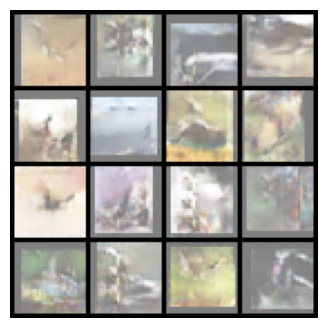

In [18]:
# Quick GAN training loop (few epochs) and sample generation
from torchvision.utils import make_grid

G = Generator(nz=nz, ngf=ngf, nc=nc).to(device)
D = Discriminator(nc=nc, ndf=ndf).to(device)

criterion_gan = nn.BCEWithLogitsLoss()
optimizerD = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
optimizerG = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))


num_gan_epochs = 50
for epoch in range(num_gan_epochs):
    for i, (imgs, _) in enumerate(trainloader):  # CIFAR-10
        imgs = imgs.to(device)

        bsz = imgs.size(0)
        real_labels = torch.ones(bsz, device=device)
        fake_labels = torch.zeros(bsz, device=device)

        # Training D on real
        optimizerD.zero_grad()
        out_real = D(imgs)
        loss_real = criterion_gan(out_real, real_labels)

        # Training D on fake
        z = torch.randn(bsz, nz, 1, 1, device=device)
        fake_imgs = G(z)
        out_fake = D(fake_imgs.detach())
        loss_fake = criterion_gan(out_fake, fake_labels)

        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizerD.step()

        # Training G
        optimizerG.zero_grad()
        out_fake_for_G = D(fake_imgs)
        loss_G = criterion_gan(out_fake_for_G, real_labels)
        loss_G.backward()
        optimizerG.step()

    print(f"GAN Epoch [{epoch+1}/{num_gan_epochs}] - D loss: {loss_D.item():.4f}, G loss: {loss_G.item():.4f}")

# Generating a small batch of synthetic images for inspection
G.eval()
with torch.no_grad():
    z = torch.randn(16, nz, 1, 1, device=device)
    synth_imgs = G(z).cpu()  # shape [16, 3, 32, 32]

grid = make_grid(synth_imgs, nrow=4, normalize=True, value_range=(-1, 1))
plt.figure(figsize=(4,4))
plt.axis("off")
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.show()
